# Comprension de los datos y EDA - Modelo de riesgo crediticio (PI M5)

**Pregunta de negocio.** Que caracteristicas del solicitante, del credito y de su historial en la central de riesgo
anticipan que **no pagara a tiempo**? Queremos entender los datos antes de modelar para elegir bien la limpieza,
la imputacion y las features.

**Estructura del notebook**

1. Exploracion inicial (shape, tipos, nulos, cardinalidad, balance del target)
2. Analisis univariable (distribucion de cada variable)
3. Analisis bivariable (cada variable contra la mora)
4. Analisis multivariable (correlaciones, multicolinealidad, cruces)
5. Conclusiones y decisiones para la ingenieria de caracteristicas

A lo largo del notebook trabajamos con **`mora = 1 - Pago_atiempo`** como evento de interes (1 = no pago a tiempo).

## 0. Setup y carga

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


def buscar_raiz(nombre="Base_de_datos.csv"):
    """Sube por el arbol de carpetas hasta encontrar el dataset (permite correr el notebook desde cualquier cwd)."""
    actual = Path.cwd().resolve()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / nombre).exists():
            return carpeta
    raise FileNotFoundError(f"No se encontro {nombre} subiendo desde {actual}")


RAIZ = buscar_raiz()
RUTA_DATOS = RAIZ / "Base_de_datos.csv"
print("Raiz del proyecto:", RAIZ)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
COLOR_MORA = "#d62728"

Raiz del proyecto: E:\pi-m5-riesgo-crediticio


In [2]:
df = pd.read_csv(RUTA_DATOS, parse_dates=["fecha_prestamo"])
df["mora"] = 1 - df["Pago_atiempo"]
TASA_GLOBAL = df["mora"].mean()
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]} | Tasa de mora global: {TASA_GLOBAL:.2%}")

Filas: 10,763 | Columnas: 24 | Tasa de mora global: 4.75%


## 1. Exploracion inicial de datos

### 1.1 Estructura, tipos y cardinalidad

In [3]:
resumen = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
    "cardinalidad": df.nunique(),
    "ejemplo": df.iloc[0],
})
resumen

,dtype,nulos,pct_nulos,cardinalidad,ejemplo
tipo_credito,int64,0,0.00,6,7
fecha_prestamo,datetime64[us],0,0.00,10758,2024-12-21 11:31:35
capital_prestado,float64,0,0.00,7306,"3,692,160.00"
plazo_meses,int64,0,0.00,18,10
edad_cliente,int64,0,0.00,54,42
tipo_laboral,str,0,0.00,2,Independiente
salario_cliente,int64,0,0.00,1385,8000000
total_otros_prestamos,int64,0,0.00,1538,2500000
cuota_pactada,int64,0,0.00,9836,341296
puntaje,float64,0,0.00,248,88.77


**Conclusion.** Por cardinalidad y significado, clasificamos las variables asi:

- **Categoricas**: `tipo_credito` (6 valores, entero que codifica un producto), `tipo_laboral` (2), `tendencia_ingresos` (3 reales + basura).
- **Numericas continuas**: montos (`capital_prestado`, `salario_cliente`, `cuota_pactada`, saldos, ingresos estimados) y scores.
- **Numericas discretas / conteos**: `plazo_meses`, `edad_cliente`, `cant_creditosvigentes`, `huella_consulta`, `creditos_sector*`.
- **Fecha**: `fecha_prestamo`, util para analisis temporal y para derivar mes / antiguedad, no como feature cruda.

### 1.2 Mapa de nulos

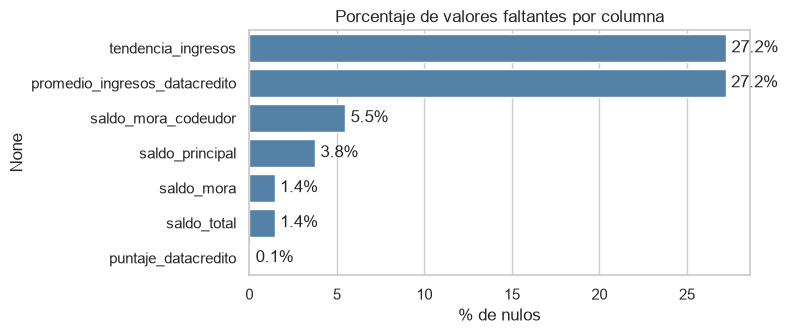

Nulos simultaneos promedio_ingresos + tendencia: 2930


In [4]:
nulos = df.isna().mean().mul(100).round(2).sort_values(ascending=False)
nulos = nulos[nulos > 0]

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=nulos.values, y=nulos.index, ax=ax, color="steelblue")
for i, v in enumerate(nulos.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
ax.set_xlabel("% de nulos")
ax.set_title("Porcentaje de valores faltantes por columna")
plt.tight_layout()
plt.show()

# Los nulos de ingresos de la central vienen juntos?
print("Nulos simultaneos promedio_ingresos + tendencia:",
      (df["promedio_ingresos_datacredito"].isna() & df["tendencia_ingresos"].isna()).sum())

**Conclusion.** Los nulos no son aleatorios: `promedio_ingresos_datacredito` y `tendencia_ingresos` faltan casi
siempre **juntos** (2.930 de 2.932 casos), lo que indica que la central no pudo estimar ingresos para ese cliente,
tipicamente por historia crediticia corta. Los saldos faltan en un grupo mucho menor. En la seccion 3 verificamos si
"tener nulo" se asocia a mayor mora, lo que justificaria crear un indicador de faltante ademas de imputar.

### 1.3 Balance de la clase objetivo

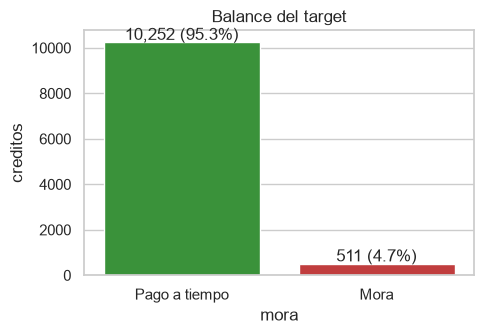

In [5]:
fig, ax = plt.subplots(figsize=(5, 3.5))
conteo = df["mora"].value_counts().rename({0: "Pago a tiempo", 1: "Mora"})
sns.barplot(x=conteo.index, y=conteo.values, ax=ax, palette=["#2ca02c", COLOR_MORA])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 100, f"{v:,} ({v / len(df):.1%})", ha="center")
ax.set_ylabel("creditos")
ax.set_title("Balance del target")
plt.tight_layout()
plt.show()

**Conclusion.** Solo 511 de 10.763 creditos (4,75%) cayeron en mora. Es un problema de **clases desbalanceadas**:
el modelo se evaluara con ROC-AUC, PR-AUC, recall y F1 sobre la clase `mora`, y en el entrenamiento se usara
ponderacion de clases. Ademas, con ~500 positivos, hay que ser cuidadosos con la validacion cruzada (usar
`StratifiedKFold`) para que cada fold tenga suficientes casos de mora.

## 2. Analisis univariable

### 2.1 Variables categoricas

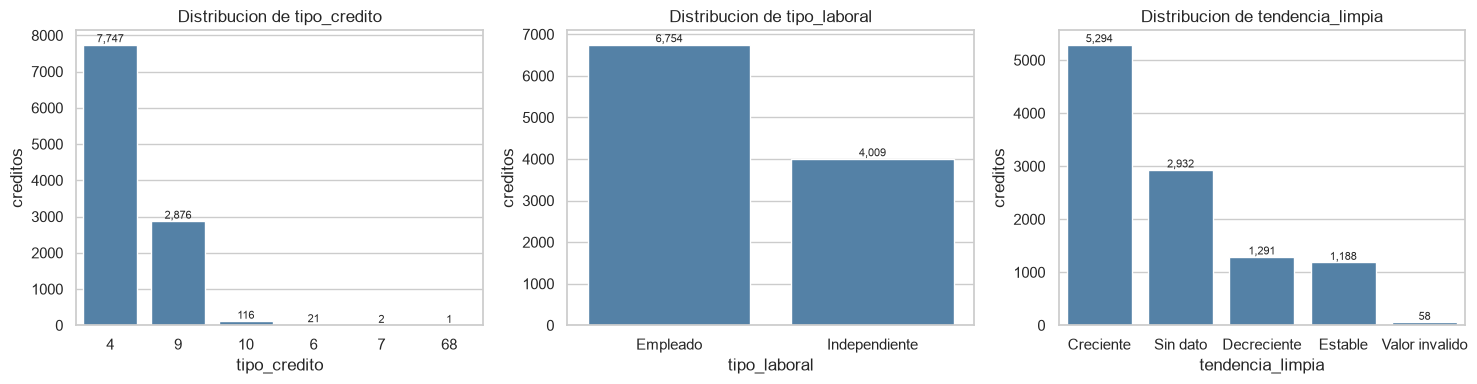

tipo_credito: {4: 7747, 9: 2876, 10: 116, 6: 21, 7: 2, 68: 1}


In [6]:
# tendencia_ingresos: separamos las 3 categorias reales de los valores numericos mal cargados
CATS_TENDENCIA = ["Creciente", "Estable", "Decreciente"]
df["tendencia_limpia"] = np.select(
    [df["tendencia_ingresos"].isin(CATS_TENDENCIA), df["tendencia_ingresos"].isna()],
    [df["tendencia_ingresos"], "Sin dato"],
    default="Valor invalido",
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tipo_credito", "tipo_laboral", "tendencia_limpia"]):
    orden = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=orden, ax=ax, color="steelblue")
    ax.set_title(f"Distribucion de {col}")
    ax.set_ylabel("creditos")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()
print("tipo_credito:", df["tipo_credito"].value_counts().to_dict())

**Conclusion.**

- `tipo_credito`: dos productos dominan (4 con 7.747 casos y 9 con 2.876); los codigos 6, 7, 10 y 68 suman 140 casos.
  Los codigos con menos de 30 registros se agruparan en una categoria "Otro" para evitar que el modelo aprenda ruido.
- `tipo_laboral`: 63% empleados, 37% independientes; sin nulos.
- `tendencia_ingresos`: 5.294 "Creciente", 1.188 "Estable", 1.291 "Decreciente", **2.932 sin dato y 58 valores invalidos**
  (numeros como 8315 o -566272 que parecen un ingreso pegado en la columna equivocada). Los invalidos se tratan como nulo.

### 2.2 Variables numericas: distribuciones

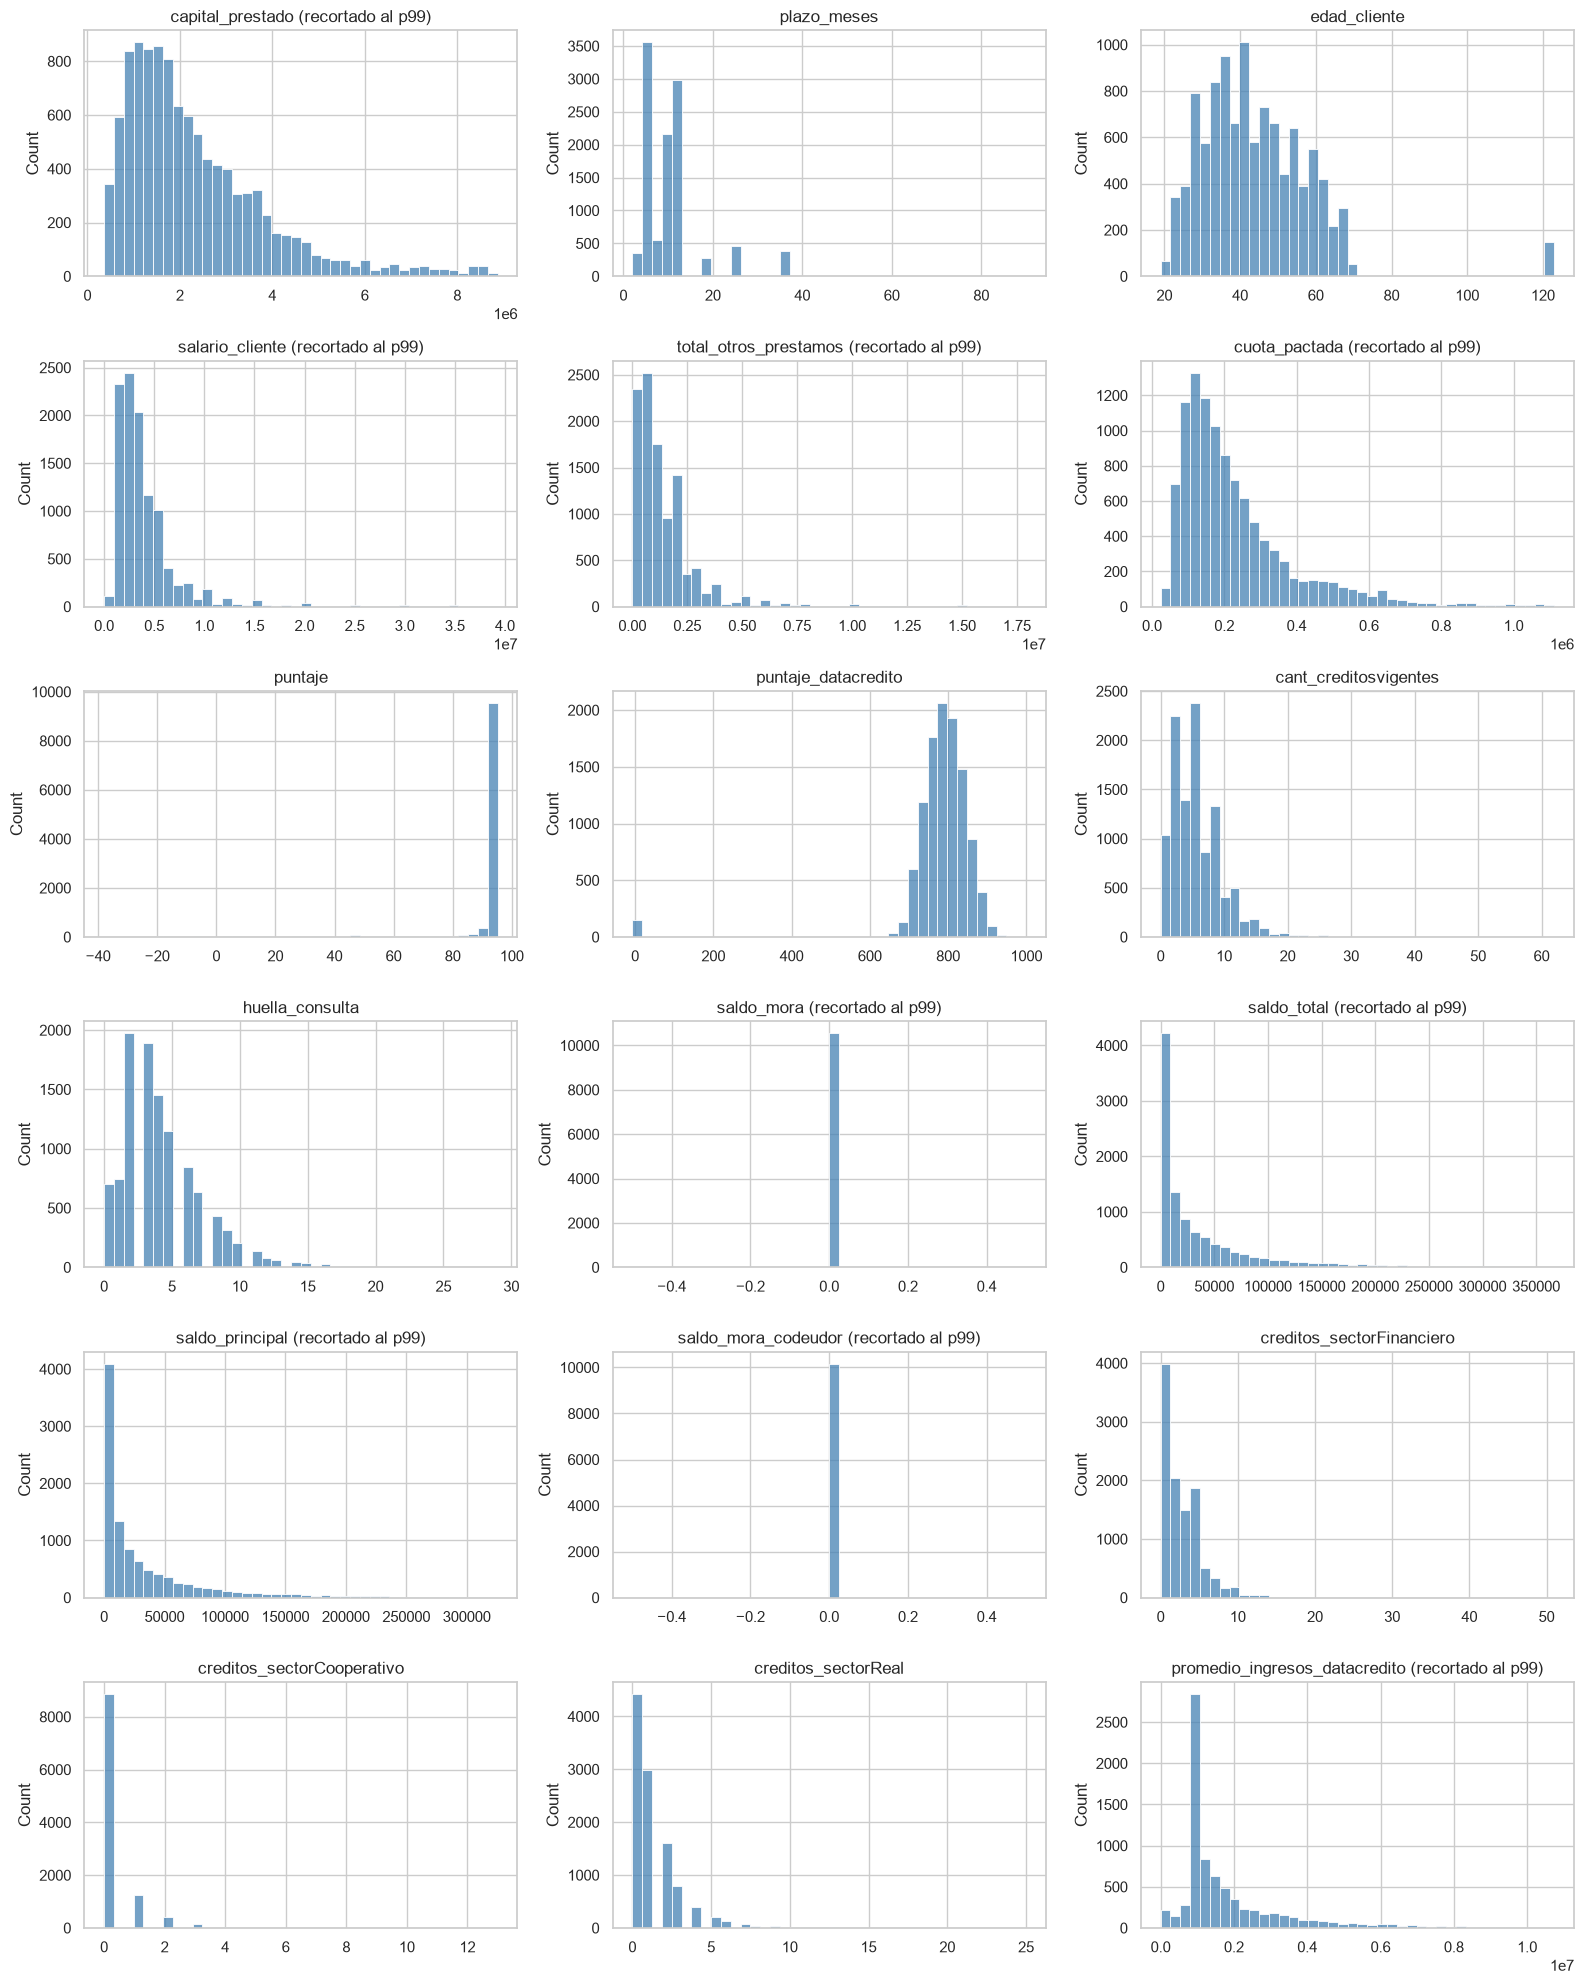

In [7]:
NUMERICAS = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente", "total_otros_prestamos", "cuota_pactada",
    "puntaje", "puntaje_datacredito", "cant_creditosvigentes", "huella_consulta", "saldo_mora", "saldo_total",
    "saldo_principal", "saldo_mora_codeudor", "creditos_sectorFinanciero", "creditos_sectorCooperativo",
    "creditos_sectorReal", "promedio_ingresos_datacredito",
]
fig, axes = plt.subplots(6, 3, figsize=(16, 20))
for ax, col in zip(axes.flat, NUMERICAS):
    serie = df[col].dropna()
    # Los montos tienen colas muy largas: se grafican recortados al percentil 99 para poder ver la forma
    if serie.max() > 1000:
        serie = serie[serie <= serie.quantile(0.99)]
        ax.set_title(f"{col} (recortado al p99)")
    else:
        ax.set_title(col)
    sns.histplot(serie, bins=40, ax=ax, color="steelblue", kde=False)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Conclusion.**

- Los **montos** (`capital_prestado`, `salario_cliente`, `cuota_pactada`, `total_otros_prestamos`, saldos, ingresos de la
  central) tienen asimetria positiva fuerte, incluso recortando al p99. Para modelos lineales conviene una transformacion
  logaritmica; los arboles no la necesitan.
- `plazo_meses` se concentra en 6, 10 y 12 meses; hay pocos casos largos (24-36) que seran relevantes en la mora.
- `edad_cliente` es aproximadamente uniforme entre 19 y 70, con una barra aislada de 150 edades entre 121 y 123 (error de carga).
- `puntaje` no es una distribucion: el 87% de las filas vale exactamente 95,23 y el resto se dispersa hasta valores negativos.
- `puntaje_datacredito` tiene forma de campana centrada en ~790 con una cola izquierda de valores muy bajos.
- `saldo_mora` y `saldo_mora_codeudor` son casi siempre 0: menos del 1% de los clientes tenia mora al momento de la solicitud.
- Los conteos (`cant_creditosvigentes`, `huella_consulta`, `creditos_sector*`) son distribuciones tipo Poisson con colas largas.

### 2.3 Outliers

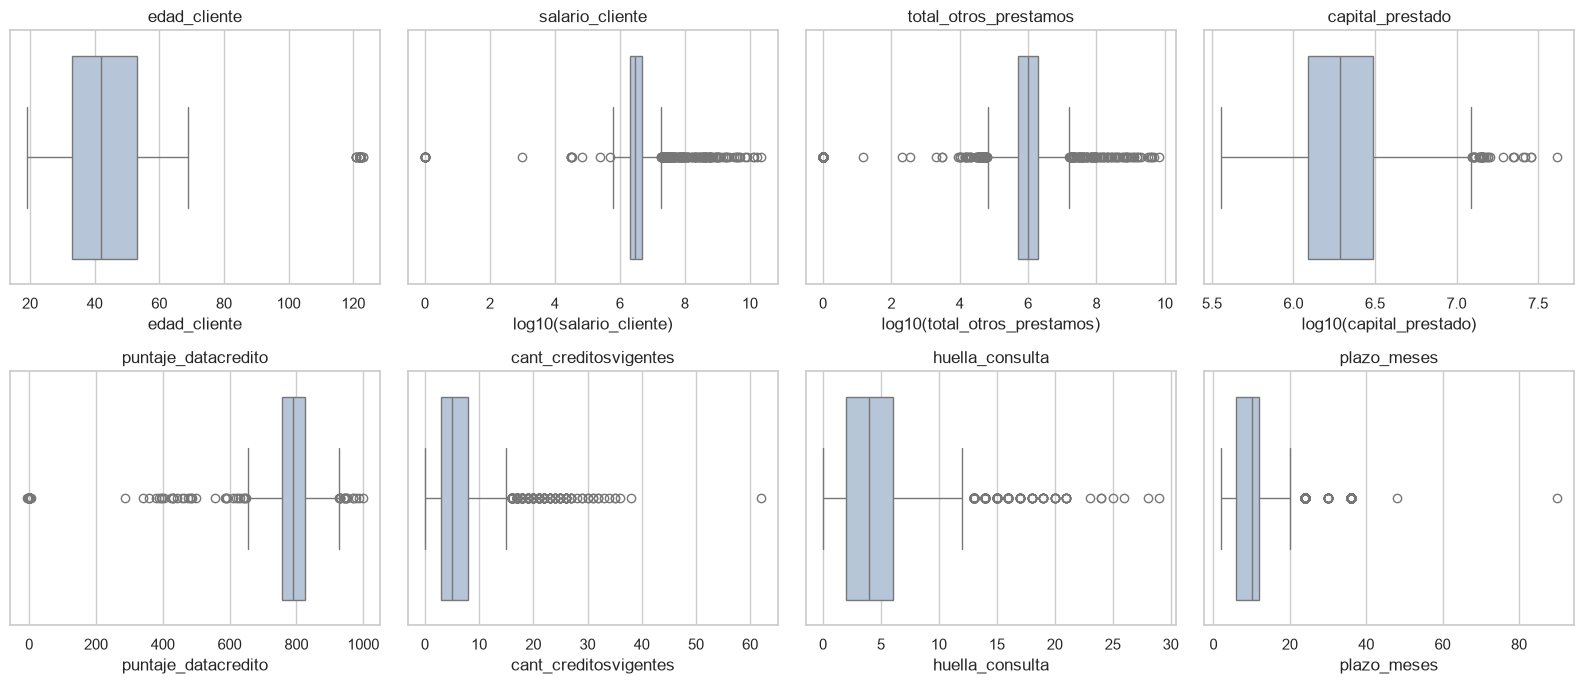

Edad >= 100: 150 | todas iguales a [122 121 123]
Salario > 100 M: 74 | salario == 0: 24
puntaje_datacredito < 150: 147
Percentil 99 de salario: 39,553,562


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
cols_box = ["edad_cliente", "salario_cliente", "total_otros_prestamos", "capital_prestado",
            "puntaje_datacredito", "cant_creditosvigentes", "huella_consulta", "plazo_meses"]
for ax, col in zip(axes.flat, cols_box):
    serie = df[col].dropna()
    if serie.max() > 1e6:
        sns.boxplot(x=np.log10(serie.clip(lower=1)), ax=ax, color="lightsteelblue")
        ax.set_xlabel(f"log10({col})")
    else:
        sns.boxplot(x=serie, ax=ax, color="lightsteelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("Edad >= 100:", (df["edad_cliente"] >= 100).sum(), "| todas iguales a",
      df.loc[df["edad_cliente"] >= 100, "edad_cliente"].unique())
print("Salario > 100 M:", (df["salario_cliente"] > 1e8).sum(), "| salario == 0:", (df["salario_cliente"] == 0).sum())
print("puntaje_datacredito < 150:", (df["puntaje_datacredito"] < 150).sum())
print("Percentil 99 de salario:", f"{df['salario_cliente'].quantile(0.99):,.0f}")

**Conclusion.** Los outliers son de dos tipos y se tratan distinto:

- **Errores de carga**: 150 clientes con edad entre 121 y 123 (imposible, casi seguro un placeholder), salarios de miles de
  millones (probablemente cargados en centavos o con ceros de mas) y 147 casos de `puntaje_datacredito` negativo o < 150
  (la central usa un rango de 150 a 950). Se corrigen en `ft_engineering.py`: las edades >= 100 pasan a nulo e imputan, los salarios se acotan (winsorizacion al p99) y los scores fuera de rango pasan a nulo.
- **Valores extremos reales**: clientes con 50 creditos vigentes o 29 consultas recientes. Son plausibles y ademas
  informativos para riesgo; se conservan. Los modelos de arboles son robustos a ellos y para la regresion logistica
  el escalado robusto / log los amortigua.

## 3. Analisis bivariable (cada variable contra la mora)

### 3.1 Funciones auxiliares

In [9]:
def tasa_mora_categorica(col, ax=None, min_casos=1):
    """Barplot de tasa de mora por categoria, con la tasa global como referencia."""
    g = df.groupby(col)["mora"].agg(["count", "mean"]).query("count >= @min_casos").sort_values("mean")
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.barplot(x=g.index.astype(str), y=g["mean"], ax=ax, color=COLOR_MORA)
    ax.axhline(TASA_GLOBAL, ls="--", color="gray", label=f"global {TASA_GLOBAL:.1%}")
    for i, (n, m) in enumerate(zip(g["count"], g["mean"])):
        ax.text(i, m + 0.003, f"{m:.1%}\n(n={n:,})", ha="center", fontsize=8)
    ax.set_ylabel("tasa de mora")
    ax.set_title(f"Tasa de mora por {col}")
    ax.legend()
    return g


def tasa_mora_numerica(col, q=5, ax=None):
    """Tasa de mora por quintil (o bins iguales si hay pocos valores distintos)."""
    try:
        bins = pd.qcut(df[col], q, duplicates="drop")
    except ValueError:
        bins = pd.cut(df[col], q)
    g = df.groupby(bins, observed=True)["mora"].agg(["count", "mean"])
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.barplot(x=[str(i) for i in g.index], y=g["mean"], ax=ax, color=COLOR_MORA)
    ax.axhline(TASA_GLOBAL, ls="--", color="gray")
    ax.set_ylabel("tasa de mora")
    ax.set_title(f"Tasa de mora por rango de {col}")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    return g

### 3.2 Variables categoricas vs mora

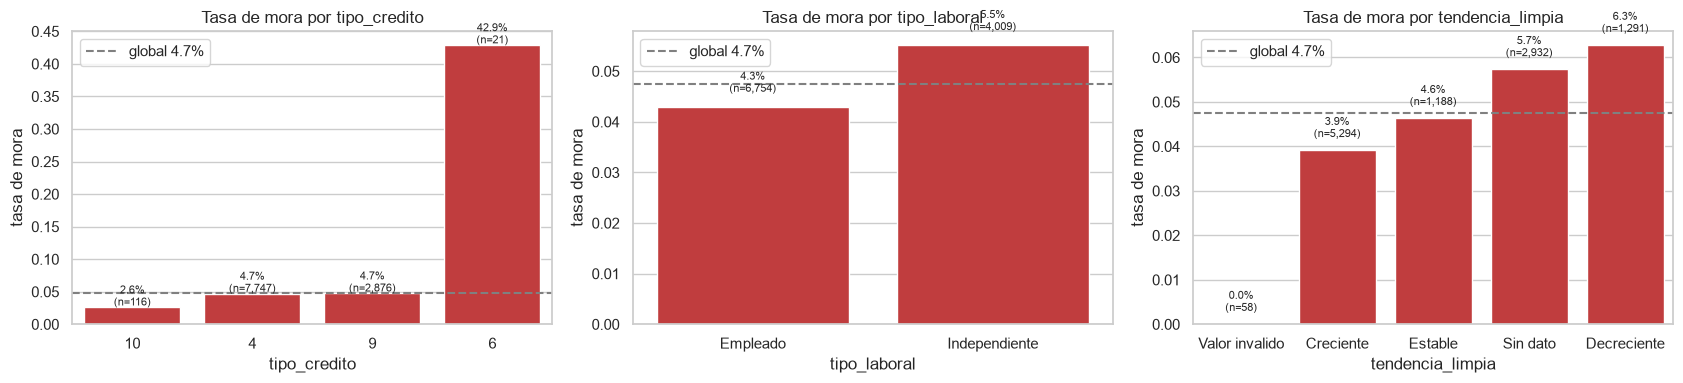

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
g1 = tasa_mora_categorica("tipo_credito", axes[0], min_casos=20)
g2 = tasa_mora_categorica("tipo_laboral", axes[1])
g3 = tasa_mora_categorica("tendencia_limpia", axes[2])
plt.tight_layout()
plt.show()

**Conclusion.**

- `tipo_laboral`: los independientes tienen mas mora (5,5%) que los empleados (4,3%). Diferencia moderada pero
  consistente con la intuicion de negocio (ingresos menos estables).
- `tendencia_limpia`: la mora crece de "Creciente" (3,9%) a "Estable" (4,6%) y "Decreciente" (6,3%). Y los clientes
  **sin dato** de la central tienen 5,7%: el nulo es informativo y merece su propia categoria / indicador.
- `tipo_credito`: 4 y 9 tienen la misma tasa (4,7%); el 10 es mas seguro (2,6%) y el 6, con 21 casos, tiene 43% de mora.
  Con tan pocos casos no se puede confiar en ese numero, otra razon para agrupar los codigos raros en "Otro".

### 3.3 Plazo del credito vs mora

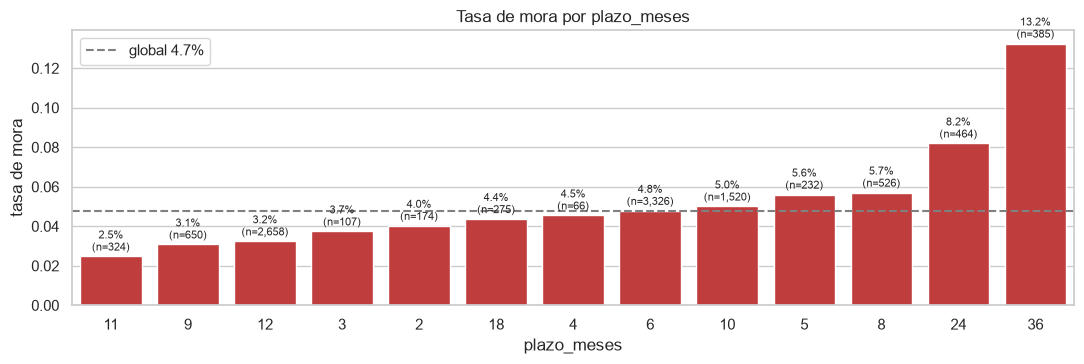

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.8))
g = tasa_mora_categorica("plazo_meses", ax, min_casos=50)
plt.tight_layout()
plt.show()

**Conclusion.** El plazo es una de las variables mas claras: los creditos a **24 meses (8,2%) y 36 meses (13,2%)** casi
triplican la mora de los plazos cortos de 9 a 12 meses (2,5% a 3,2%). Un plazo largo expone al cliente a mas eventos
adversos y suele asociarse a montos mayores. Ademas del plazo crudo, en el feature engineering creamos un indicador
de "plazo largo" (>= 24 meses).

### 3.4 Variables numericas vs mora

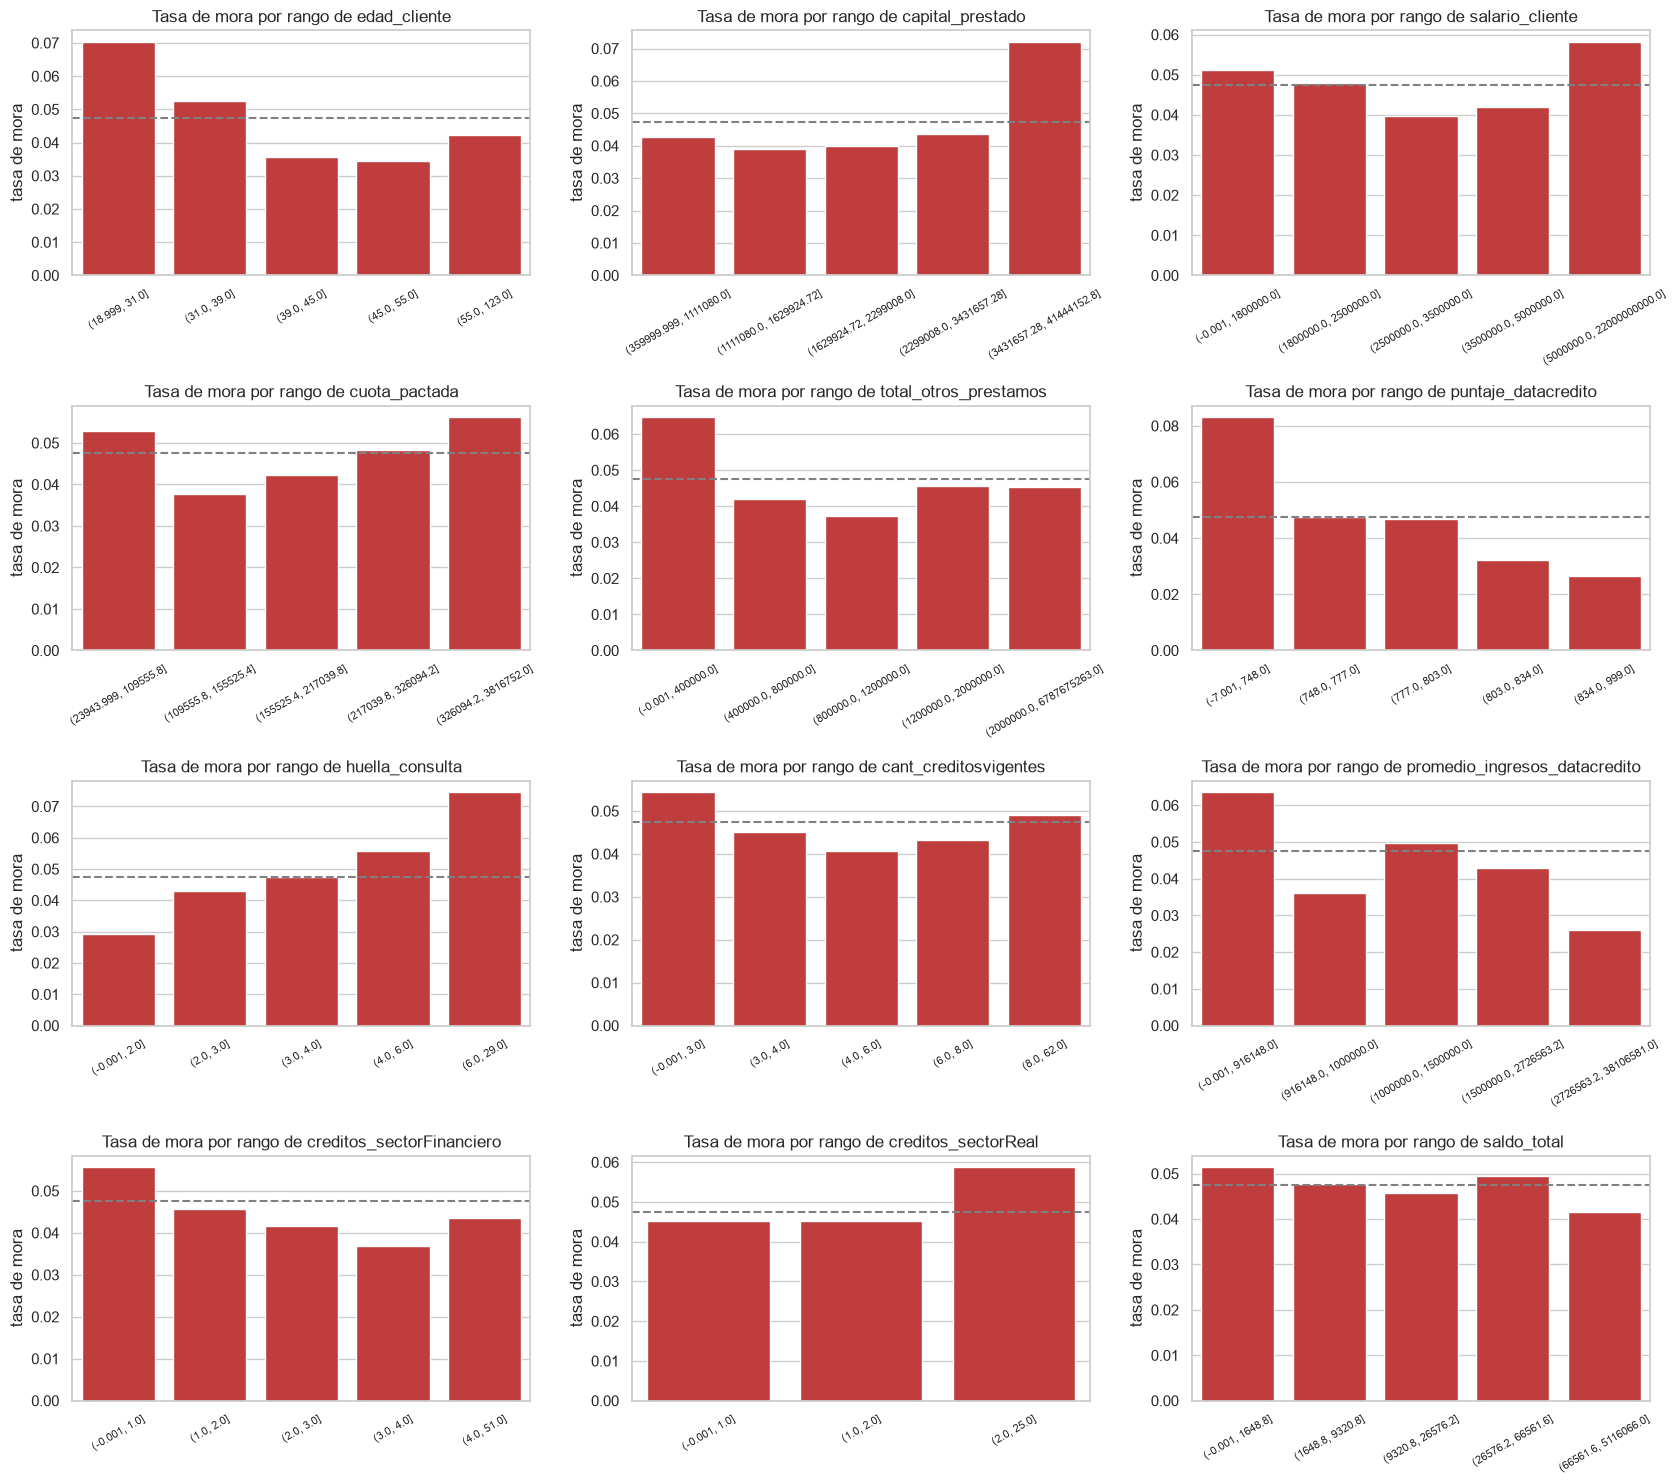

In [12]:
cols_num = ["edad_cliente", "capital_prestado", "salario_cliente", "cuota_pactada", "total_otros_prestamos",
            "puntaje_datacredito", "huella_consulta", "cant_creditosvigentes", "promedio_ingresos_datacredito",
            "creditos_sectorFinanciero", "creditos_sectorReal", "saldo_total"]
fig, axes = plt.subplots(4, 3, figsize=(17, 15))
for ax, col in zip(axes.flat, cols_num):
    tasa_mora_numerica(col, ax=ax)
plt.tight_layout()
plt.show()

**Conclusion.** Ordenando por fuerza de la senal:

- `puntaje_datacredito` es el mejor predictor legitimo: la mora baja monotonamente de **8,3%** en el quintil mas bajo
  (< 748) a **2,7%** en el mas alto (> 834). Un buen score externo triplica la seguridad del credito.
- `huella_consulta`: mas consultas recientes, mas mora, tambien de forma monotona (2,9% con <= 2 consultas vs 7,5% con
  > 6). Es el clasico "cliente buscando credito en todos lados".
- `edad_cliente`: los menores de 31 tienen 7,0% de mora, el doble que los de 40 a 55 (3,4% a 3,6%).
- `capital_prestado`: el quintil mas alto (> 3,4 M) salta a 7,2% mientras el resto esta entre 3,9% y 4,4%.
- `promedio_ingresos_datacredito`: los ingresos estimados mas altos tienen la menor mora (2,6%); los mas bajos, 6,4%.
- `creditos_sectorFinanciero`: tener 0 o 1 credito bancario es *peor* (5,6%) que tener varios: la falta de historia
  penaliza. En cambio muchos creditos en el sector real (> 2) suben la mora a 5,9%.
- `salario_cliente`, `cuota_pactada`, `saldo_total` y `total_otros_prestamos` muestran relaciones debiles o en forma de U;
  su valor vendra mas de los **ratios** (cuota / ingreso, deuda / ingreso) que del monto absoluto.

### 3.5 Distribucion de las variables clave segun mora

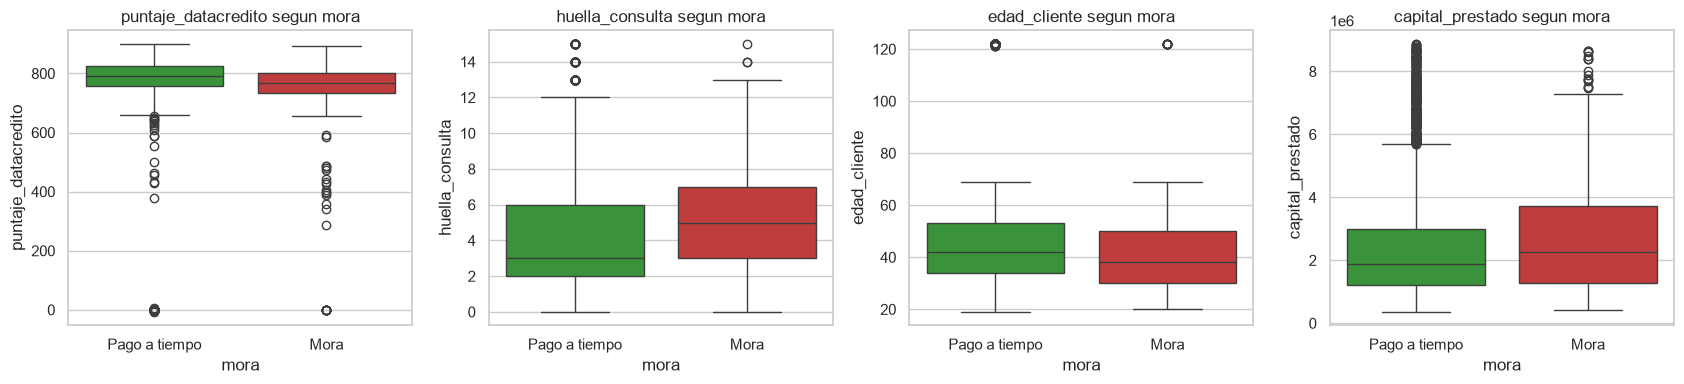

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, col in zip(axes, ["puntaje_datacredito", "huella_consulta", "edad_cliente", "capital_prestado"]):
    datos = df[df[col] <= df[col].quantile(0.99)]
    sns.boxplot(data=datos, x="mora", y=col, ax=ax, palette=["#2ca02c", COLOR_MORA])
    ax.set_xticklabels(["Pago a tiempo", "Mora"])
    ax.set_title(f"{col} segun mora")
plt.tight_layout()
plt.show()

**Conclusion.** Los boxplots confirman lo anterior con otra lente: la mediana de `puntaje_datacredito` de los morosos
esta claramente por debajo de la de los cumplidores, los morosos tienen mas consultas recientes y son mas jovenes, y
piden capitales algo mayores. Ninguna variable separa perfectamente ambos grupos (hay mucho solapamiento), por eso se
necesita un modelo multivariado y no una regla simple.

### 3.6 Mora en el tiempo

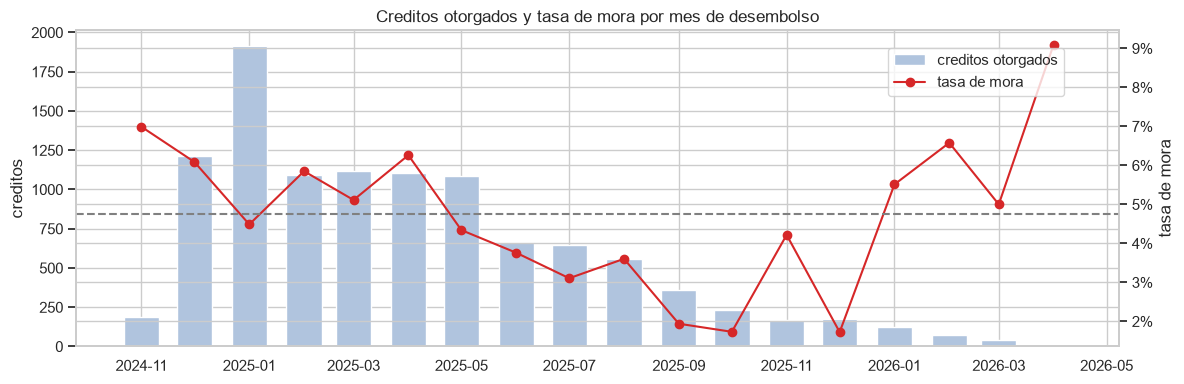

In [14]:
mensual = (df.set_index("fecha_prestamo").resample("MS")["mora"].agg(["count", "mean"]))
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(mensual.index, mensual["count"], width=20, color="lightsteelblue", label="creditos otorgados")
ax1.set_ylabel("creditos")
ax2 = ax1.twinx()
ax2.plot(mensual.index, mensual["mean"], color=COLOR_MORA, marker="o", label="tasa de mora")
ax2.axhline(TASA_GLOBAL, ls="--", color="gray")
ax2.set_ylabel("tasa de mora")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax1.set_title("Creditos otorgados y tasa de mora por mes de desembolso")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

**Conclusion.** El volumen de creditos cae fuerte desde mediados de 2025 y la tasa de mora tambien baja (de ~6% a fines
de 2024 a ~2% en el ultimo trimestre de 2025). La explicacion mas probable no es que los clientes mejoraron sino que los
creditos recientes **todavia no tuvieron tiempo de caer en mora** (censura): un credito a 12 meses desembolsado en 2026
apenas empezo a pagarse. Implicancias:

- La fecha no se usa como feature cruda (no generaliza a creditos futuros).
- Para el monitoreo de drift (`model_monitoring.py`) usaremos los meses mas recientes como "datos nuevos" y esperamos
  detectar deriva justamente por este efecto.

### 3.7 Los nulos, se asocian a mas mora?

In [15]:
filas = []
for col in ["promedio_ingresos_datacredito", "saldo_mora", "saldo_principal", "saldo_mora_codeudor", "puntaje_datacredito"]:
    g = df.groupby(df[col].isna())["mora"].agg(["count", "mean"])
    filas.append({"columna": col, "n_nulos": int(g.loc[True, "count"]),
                  "mora_con_dato": g.loc[False, "mean"], "mora_sin_dato": g.loc[True, "mean"]})
pd.DataFrame(filas).style.format({"mora_con_dato": "{:.1%}", "mora_sin_dato": "{:.1%}"})

,columna,n_nulos,mora_con_dato,mora_sin_dato
0,promedio_ingresos_datacredito,2930,4.4%,5.7%
1,saldo_mora,156,4.7%,7.1%
2,saldo_principal,405,4.7%,7.2%
3,saldo_mora_codeudor,590,4.6%,6.8%
4,puntaje_datacredito,6,4.7%,16.7%


**Conclusion.** En todas las columnas, los clientes **sin dato tienen mas mora** que los que si lo tienen
(5,7% vs 4,4% para ingresos de la central; ~7% vs 4,7% para los saldos). La ausencia de informacion en la central es en
si misma una senal de riesgo. Decision para `ft_engineering.py`: imputar (mediana para ingresos, 0 para saldos) **y**
agregar indicadores binarios de faltante para las columnas con mas de un 1% de nulos.

### 3.8 Alerta: `puntaje` es fuga de informacion (target leakage)

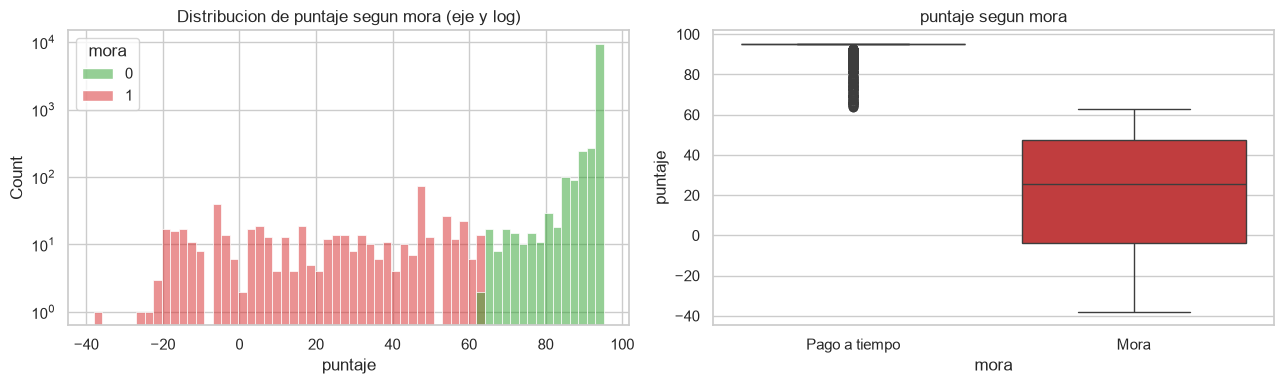

Correlacion puntaje vs mora: -0.923
Puntaje maximo entre morosos: 62.67
Puntaje minimo entre cumplidores: 63.81
Morosos con puntaje = 95.23: 0


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df, x="puntaje", hue="mora", bins=60, ax=axes[0], palette=["#2ca02c", COLOR_MORA], stat="count")
axes[0].set_yscale("log")
axes[0].set_title("Distribucion de puntaje segun mora (eje y log)")
sns.boxplot(data=df, x="mora", y="puntaje", ax=axes[1], palette=["#2ca02c", COLOR_MORA])
axes[1].set_xticklabels(["Pago a tiempo", "Mora"])
axes[1].set_title("puntaje segun mora")
plt.tight_layout()
plt.show()

print("Correlacion puntaje vs mora:", round(df["puntaje"].corr(df["mora"]), 3))
print("Puntaje maximo entre morosos:", df.loc[df["mora"] == 1, "puntaje"].max().round(2))
print("Puntaje minimo entre cumplidores:", df.loc[df["mora"] == 0, "puntaje"].min().round(2))
print("Morosos con puntaje = 95.23:", ((df["puntaje"].round(2) == 95.23) & (df["mora"] == 1)).sum())

**Conclusion (hallazgo mas importante del EDA).** `puntaje` separa **perfectamente** las clases: todo moroso tiene
puntaje <= 62,7 y todo cumplidor tiene puntaje >= 63,8; correlacion de -0,92 con la mora. Ninguna variable conocida
*antes* de otorgar el credito puede predecir asi el resultado, y ademas `puntaje` no correlaciona con nada del historial
(0,05 con `puntaje_datacredito`). Todo indica que es un score interno **calculado despues** del comportamiento de pago,
es decir, contiene el target.

Decision: **`puntaje` se excluye del modelado.** Incluirla daria un modelo con AUC ~1,0 en test que fallaria por completo
en produccion, donde ese valor no existe al momento de decidir. Este tipo de fuga es exactamente lo que un pipeline de
validacion debe atrapar antes de desplegar.

## 4. Analisis multivariable

### 4.1 Matriz de correlacion

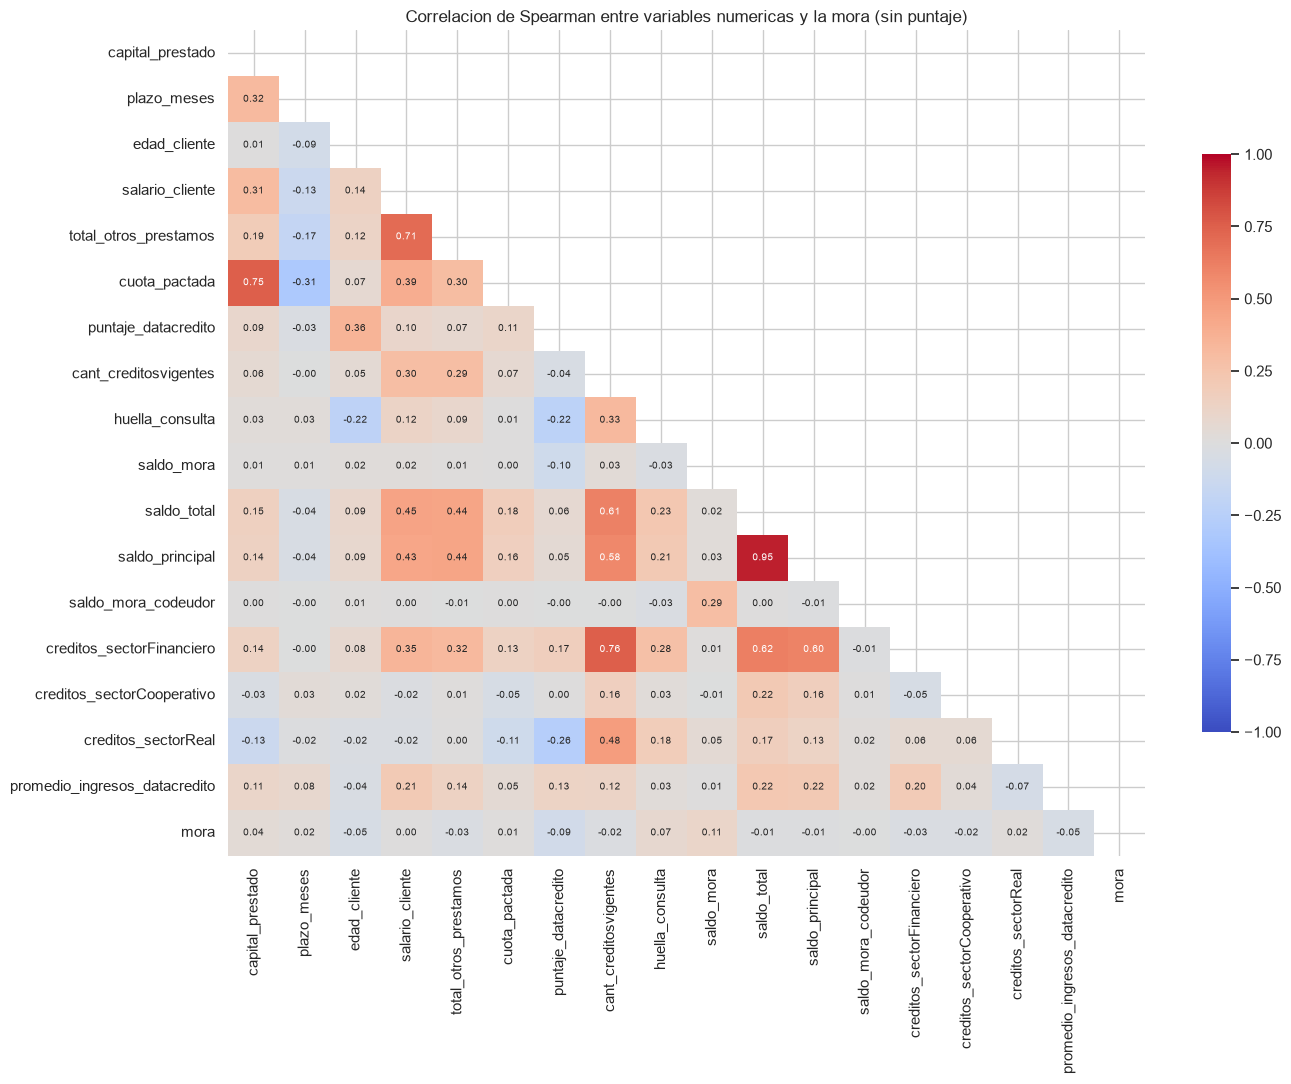

In [17]:
cols_corr = [c for c in NUMERICAS if c != "puntaje"] + ["mora"]
corr = df[cols_corr].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7}, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Correlacion de Spearman entre variables numericas y la mora (sin puntaje)")
plt.tight_layout()
plt.show()

**Conclusion.** Usamos Spearman porque los montos son muy asimetricos. Con la mora, las correlaciones son debiles
(|rho| < 0,1), lo esperable en riesgo crediticio: ningun atributo solo explica el default, y por eso el modelo tiene
que combinar muchos. Las mas altas son `huella_consulta` (+), `puntaje_datacredito` (-) y `edad_cliente` (-), en linea
con el analisis bivariable. Entre variables explicativas si hay bloques correlacionados, que analizamos a continuacion.

### 4.2 Multicolinealidad: pares altamente correlacionados

In [18]:
corr_x = df[[c for c in NUMERICAS if c != "puntaje"]].corr().abs()
pares = (
    corr_x.where(np.triu(np.ones(corr_x.shape), k=1).astype(bool))
    .stack().rename("corr_abs").reset_index()
    .rename(columns={"level_0": "var_1", "level_1": "var_2"})
    .query("corr_abs > 0.5").sort_values("corr_abs", ascending=False)
)
pares.style.format({"corr_abs": "{:.2f}"})

,var_1,var_2,corr_abs
132,cant_creditosvigentes,creditos_sectorFinanciero,0.79
5,capital_prestado,cuota_pactada,0.76
181,saldo_total,saldo_principal,0.73
55,salario_cliente,total_otros_prestamos,0.60
134,cant_creditosvigentes,creditos_sectorReal,0.54
200,saldo_principal,creditos_sectorFinanciero,0.54


**Conclusion.** Hay 6 pares con |r| > 0,5 y todos tienen una explicacion estructural:

- `capital_prestado` ~ `cuota_pactada` (0,76): la cuota se calcula a partir del capital y el plazo.
- `cant_creditosvigentes` ~ `creditos_sectorFinanciero` (0,79) y ~ `creditos_sectorReal` (0,54): el total es la suma de los sectores.
- `saldo_total` ~ `saldo_principal` (0,73): el principal es parte del total.
- `salario_cliente` ~ `total_otros_prestamos` (0,60): quien gana mas se endeuda mas.

Esto no invalida los arboles (Random Forest / XGBoost), pero si infla la varianza de los coeficientes de la regresion
logistica. En `ft_engineering.py` reemplazamos algunos pares por ratios mas informativos (cuota / salario,
deuda / salario, saldo_mora / saldo_total) que ademas tienen sentido de negocio.

### 4.3 Cruce tipo laboral x tendencia de ingresos

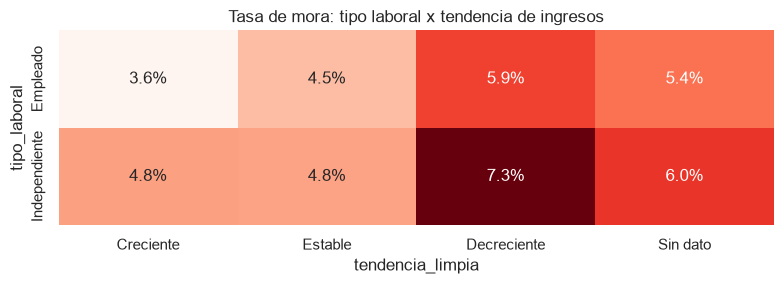

In [19]:
tabla = df.pivot_table(index="tipo_laboral", columns="tendencia_limpia", values="mora", aggfunc="mean")
tabla = tabla[["Creciente", "Estable", "Decreciente", "Sin dato"]]
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(tabla, annot=True, fmt=".1%", cmap="Reds", ax=ax, cbar=False)
ax.set_title("Tasa de mora: tipo laboral x tendencia de ingresos")
plt.tight_layout()
plt.show()

**Conclusion.** Los efectos se acumulan: un empleado con ingresos crecientes tiene 3,6% de mora; un independiente con
ingresos decrecientes, 7,3%, el doble. La interaccion es aproximadamente aditiva (no hay una celda que se dispare),
asi que los modelos lineales la capturan con ambas variables y los arboles la aprenden solos.

### 4.4 Cruce tipo de credito x plazo

In [20]:
ct = pd.crosstab(df["tipo_credito"], df["plazo_meses"])
ct

plazo_meses,2,3,4,5,6,7,8,9,10,11,12,18,20,24,30,36,48,90
tipo_credito,,,,,,,,,,,,,,,,,,
4,0,0,0,0,3236,0,439,0,387,0,2576,269,13,454,15,358,0,0
6,0,0,1,0,5,0,0,0,2,1,3,1,1,0,1,6,0,0
7,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
9,174,107,65,232,44,22,82,650,1125,323,52,0,0,0,0,0,0,0
10,0,0,0,0,41,0,5,0,5,0,27,5,0,10,2,21,0,0
68,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


**Conclusion.** Los productos tienen plazos muy distintos: el tipo 9 es un credito corto (2 a 12 meses, moda 10) y el
tipo 4 es mas largo (6 a 36, moda 6 y 12). Como `plazo_meses` ya captura el riesgo por duracion y `tipo_credito` se
correlaciona con el plazo, parte de la informacion es redundante; aun asi conservamos ambas porque el tipo 10 tiene
una tasa de mora distinta a igual plazo.

### 4.5 Ratios de capacidad de pago

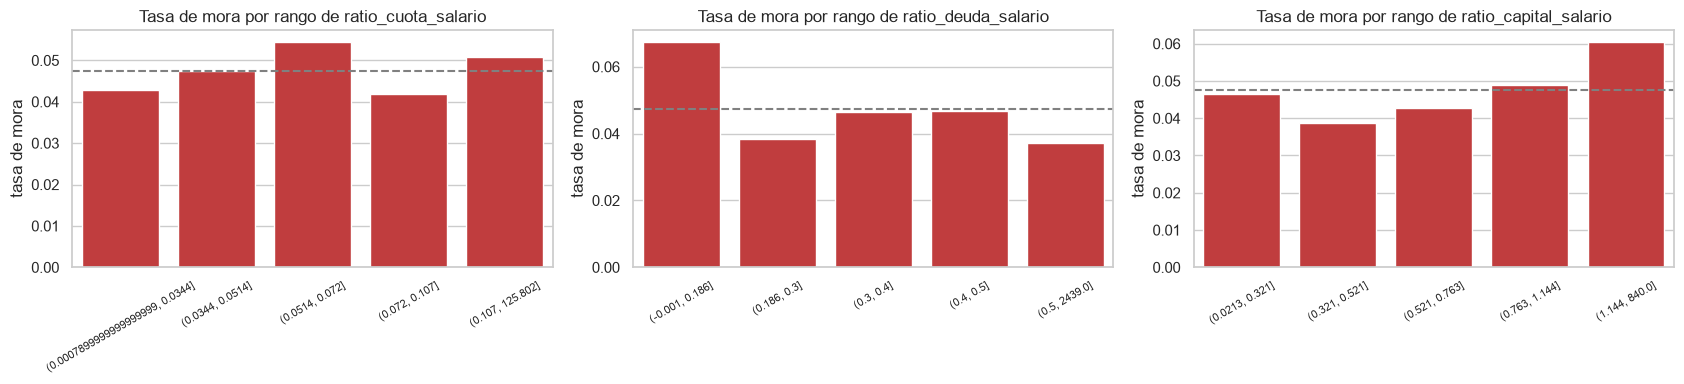

In [21]:
salario = df["salario_cliente"].replace(0, np.nan).clip(upper=df["salario_cliente"].quantile(0.99))
df["ratio_cuota_salario"] = df["cuota_pactada"] / salario
df["ratio_deuda_salario"] = df["total_otros_prestamos"].clip(upper=df["total_otros_prestamos"].quantile(0.99)) / salario
df["ratio_capital_salario"] = df["capital_prestado"] / salario

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col in zip(axes, ["ratio_cuota_salario", "ratio_deuda_salario", "ratio_capital_salario"]):
    tasa_mora_numerica(col, q=5, ax=ax)
plt.tight_layout()
plt.show()

**Conclusion.** Los ratios cuentan una historia distinta a la de los montos absolutos:

- `ratio_capital_salario`: el quintil mas alto (capital > 1,1 veces el salario) tiene 6,1% de mora contra 3,9% a 4,9% del
  resto. Pedir mas de lo que se gana en un mes es la senal mas clara de sobreendeudamiento.
- `ratio_deuda_salario`: sorprende que el quintil **mas bajo** (otras deudas < 19% del salario) sea el de mayor mora (6,7%).
  Coincide con lo visto en `creditos_sectorFinanciero`: los clientes sin deuda previa son perfiles con poca historia,
  no necesariamente mas solventes.
- `ratio_cuota_salario`: relacion debil y no monotona (entre 4,2% y 5,4%); la cuota esta acotada por la politica de
  originacion, asi que aporta poco por si sola.

Se incorporan los tres al pipeline porque son features clasicas de scoring y los arboles pueden explotar las
relaciones no lineales. Nota: se calculan con el salario acotado al p99 y sin ceros para evitar ratios infinitos.

### 4.6 Relaciones conjuntas entre las variables mas predictivas

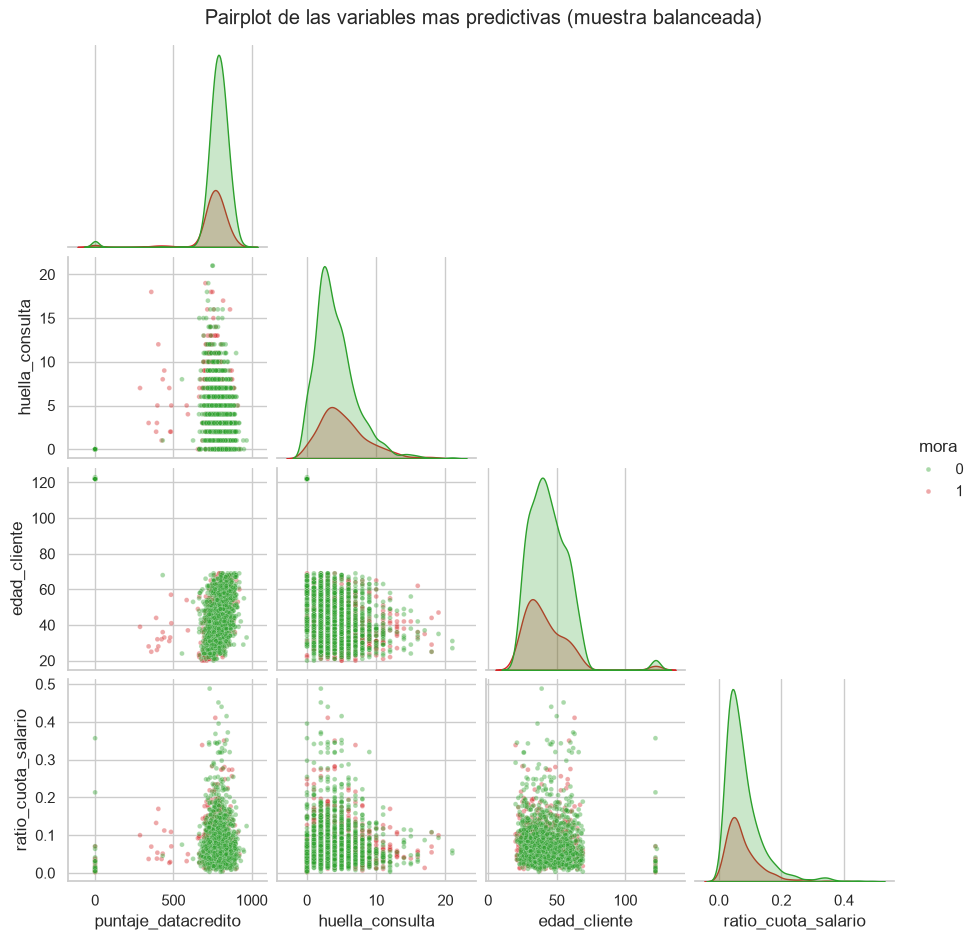

In [22]:
top = ["puntaje_datacredito", "huella_consulta", "edad_cliente", "ratio_cuota_salario", "mora"]
muestra = pd.concat([df[df["mora"] == 1], df[df["mora"] == 0].sample(1500, random_state=42)])
muestra = muestra[muestra["ratio_cuota_salario"] < 0.5]
g = sns.pairplot(muestra[top], hue="mora", palette={0: "#2ca02c", 1: COLOR_MORA},
                 plot_kws={"alpha": 0.4, "s": 12}, diag_kind="kde", corner=True, height=2.3)
g.fig.suptitle("Pairplot de las variables mas predictivas (muestra balanceada)", y=1.02)
plt.show()

**Conclusion.** En el pairplot (con una muestra de cumplidores para que la mora sea visible) los morosos se concentran
en la esquina de **puntaje bajo + muchas consultas + edad joven**, pero no forman un cluster separado: cualquier
frontera de decision va a tener falsos positivos. Esto anticipa que el modelo tendra AUC moderada (0,65 a 0,75 es lo
tipico con datos de originacion) y que el umbral de decision debera elegirse segun el costo de negocio, no en 0,5.

## 5. Conclusiones del EDA y decisiones para la ingenieria de caracteristicas

### Hallazgos principales

1. **Desbalance fuerte**: 4,75% de mora. Metricas: ROC-AUC, PR-AUC, recall y F1 de la clase mora; `StratifiedKFold`; ponderacion de clases.
2. **`puntaje` es target leakage** (separa perfectamente las clases) y se **excluye** del modelo.
3. **Senales legitimas mas fuertes**: `puntaje_datacredito` (-), `huella_consulta` (+), `edad_cliente` (-), `plazo_meses` largo (+),
   `capital_prestado` alto (+), `tendencia_ingresos` decreciente (+), `tipo_laboral` independiente (+), falta de dato en la central (+).
4. **Multicolinealidad** en bloques (capital-cuota, total-sectores, saldos) que se resuelve con ratios.
5. **Efecto temporal por censura**: los creditos recientes muestran menos mora porque aun no maduraron.

### Decisiones para `ft_engineering.py`

| Problema | Decision |
|---|---|
| `edad_cliente` >= 100 (150 casos con 121-123) | Pasar a nulo e imputar con la mediana |
| `salario_cliente`, `total_otros_prestamos` con valores extremos | Winsorizar al p99; salario 0 pasa a nulo |
| `puntaje_datacredito` < 150 o nulo | Pasar a nulo e imputar con la mediana |
| `tendencia_ingresos` con valores numericos | Tratar como nulo; categoria explicita "Sin dato" |
| `promedio_ingresos_datacredito` nulo (27%) | Imputar mediana + indicador `promedio_ingresos_datacredito_na` |
| Saldos nulos (`saldo_*`) | Imputar 0 (sin deuda reportada) + indicador de faltante |
| `tipo_credito` con codigos raros | Agrupar < 30 casos en "Otro"; one-hot encoding |
| `tipo_laboral`, `tendencia_ingresos` | One-hot encoding |
| Montos asimetricos | `log1p` para el modelo lineal; los arboles usan la variable cruda |
| Features nuevas | `ratio_cuota_salario`, `ratio_deuda_salario`, `ratio_capital_salario`, `plazo_largo` (>= 24), `tiene_mora_previa` (saldo_mora > 0), `creditos_total_sectores` |
| `fecha_prestamo` | No se usa como feature; se reserva para el split temporal del monitoreo |
| `puntaje` | **Eliminada** por fuga de informacion |